# What Contradicts What

**Supersession in the agent-memory layer needs world knowledge. This notebook supplies it as one `Noul`,
plugs it into `kgx.temporal`, and measures it against the two contradictions the corpus planted.**

The temporal layer in this repo has one rule that it cannot apply by itself. When the user says *"I've
switched to pnpm"* after saying *"I use npm"*, the second fact should supersede the first. When they say
*"I use Python"* and later *"I'm based in Berlin"*, both should stand. `kgx.temporal.TemporalGraph` knows
that `prefers` is an *alternatives* relation and that supersession only applies when the two tails are
alternatives — and then it has to ask something called `alternative_fn(a, b)`, because deciding whether
`npm` and `pnpm` compete for the same role is not a thing a string, an embedding, or a span model knows.

The README records what was tried. Embedding similarity *"does not separate genuine alternatives (npm/pnpm)
from unrelated pairs (npm/Berlin) — the distributions overlap under every template tried."* What worked
was declaring `replaces(tool → tool)` in the ontology and letting joint decoding find the switch the user
announced — which only fires when the user *says* they switched. A silent drift leaves no `replaces` edge,
and the pair lands in a review queue.

That review queue is a world-knowledge question with a yes/no answer, which is the shape a System One
model is for. `kts.JevAlternatives` is an `alternative_fn` backed by one `Noul` — *are `a` and `b`
alternatives, two options for the same role?* — with a `Choice` riding along to say what kind of pair it
is. `TemporalGraph(alternative_fn=JevAlternatives(ts))` is the whole integration.

| | decides with | needs the user to say so | measured here |
|---|---|---|---|
| **no `alternative_fn`** | nothing — logs a candidate | — | the review queue, as a baseline |
| **`embedding_alternatives`** | MiniLM cosine over the two names | no | the README's failure, reproduced |
| **`graph_alternatives`** | `replaces` edges the extractor found | **yes** | notebook 01's approach |
| **`JevAlternatives`** | a `Noul` over the two names | no | this notebook |

Needs `TYPESAFE_API_KEY`, or the cached responses in `output/typesafe_cache/`.

## 0. Setup — the memory graph, exactly as notebook 01 builds it

In [1]:
import os, sys, time, json, warnings, itertools
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import msgspec
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 46)

import kgx
import kgx.typesafe as kts
from kgx.coref import user_mentions, USER_CANON_ID
from kgx.temporal import (TemporalGraph, SUPERSEDING_RELATIONS, embedding_alternatives,
                          graph_alternatives, explicit_alternatives)
from kgx.data.conversations import SESSIONS, CONTRADICTIONS, GOLD_MEMORY_FACTS

ts = kts.CachedTypeSafe(cache_dir=ROOT / "output" / "typesafe_cache")
print(ts)
if not ts.available:
    print("TYPESAFE_API_KEY is not set -- replaying from cache; anything new will raise.")

def show(obj):
    print(json.dumps(json.loads(msgspec.json.encode(obj)), indent=2, ensure_ascii=False))

print(f"\n{len(SESSIONS)} sessions, {sum(len(s['turns']) for s in SESSIONS)} turns, "
      f"{len(GOLD_MEMORY_FACTS)} gold facts, {len(CONTRADICTIONS)} planted contradictions:")
for c in CONTRADICTIONS:
    print(f"   {c['subject']} {c['relation']} {c['old']!r} ({c['old_session']})  ->  "
          f"{c['new']!r} ({c['new_session']})")

CachedTypeSafe(model='jev-latest', cache_dir='../output/typesafe_cache', key=unset)
TYPESAFE_API_KEY is not set -- replaying from cache; anything new will raise.

5 sessions, 80 turns, 36 gold facts, 2 planted contradictions:
   Priya Raman prefers 'npm' (s1)  ->  'pnpm' (s4)
   Priya Raman prefers 'Python' (s2)  ->  'Go' (s5)


In [2]:
ROSTER = ["Priya Raman", "Dev Shah", "Marcus Webb", "Elena Vasquez", "Tomás Ferreira"]
pre = kgx.ConversationPreprocessor("Priya Raman", roster=ROSTER)
episodes = pre.episodes(SESSIONS, window=4, stride=3)

t0 = time.perf_counter()
extractor = kgx.GlinerExtractor()
mem_graphs = extractor.extract_batch(episodes, kgx.AGENT_MEMORY)
dropped = pre.clean_mentions(mem_graphs)
print(f"{len(episodes)} episodes -> {sum(len(g.mentions) for g in mem_graphs)} mentions, "
      f"{sum(len(g.edges) for g in mem_graphs)} edges in {time.perf_counter() - t0:.1f}s "
      f"({dropped} speaker-label artefacts dropped)")

registry = kgx.CanonicalRegistry(kgx.EntityResolver(threshold=0.90))
for g in mem_graphs:
    registry.add_episode(g.mentions, episode_id=g.doc_id)
all_mentions = [m for g in mem_graphs for m in g.mentions]
pins = {mid: USER_CANON_ID for mid in user_mentions(all_mentions, "Priya Raman")}
resolution_mem = registry.as_resolution()

by_session = {}
for g in mem_graphs:
    by_session.setdefault(g.meta.get("session_id"), []).append(g)
session_kgs = {sid: kgx.build_graph(by_session[sid], resolution_mem, kgx.AGENT_MEMORY, pin=pins)
               for sid in sorted(by_session)}
when = {s["session_id"]: s["timestamp"] for s in SESSIONS}
print(f"{len(session_kgs)} per-session graphs; "
      f"{sum(len(k.edges) for k in session_kgs.values())} canonical edges in all")

25 episodes -> 456 mentions, 650 edges in 38.3s (27 speaker-label artefacts dropped)


5 per-session graphs; 136 canonical edges in all


Did extraction even find the facts the contradictions are about? Supersession can only fire on facts that
exist, so check before measuring anything downstream.

In [3]:
ALT_RELATIONS = [r for r, policy in SUPERSEDING_RELATIONS.items() if policy == "alternatives"]
print("relations whose supersession needs an alternative_fn:", ALT_RELATIONS, "\n")

rows = []
for sid, kg in session_kgs.items():
    for e in kg.edges:
        if e.type in ALT_RELATIONS and e.head == USER_CANON_ID:
            rows.append({"session": sid, "relation": e.type, "tail": kg.name(e.tail),
                         "tail_type": kg.entities[e.tail].type, "conf": round(e.confidence, 2)})
U = pd.DataFrame(rows).sort_values(["relation", "session"])
display(U)

def mentions_tail(name):
    return sorted(U[U["tail"].str.casefold().str.contains(name.casefold())]["session"].unique())
for c in CONTRADICTIONS:
    print(f"{c['old']!r}: {mentions_tail(c['old'])}   {c['new']!r}: {mentions_tail(c['new'])}")

relations whose supersession needs an alternative_fn: ['prefers', 'avoids', 'uses_tool'] 



,session,relation,tail,tail_type,conf
2,s1,avoids,Jenkins,topic,0.98
3,s1,avoids,Jenkins,place,0.94
12,s2,avoids,Confluence,topic,0.97
14,s2,avoids,Confluence,organization,0.94
19,s4,avoids,npm,tool,0.87
1,s1,prefers,read model,topic,0.68
4,s1,prefers,pnpm,tool,0.93
6,s1,prefers,groovy script,tool,0.75
8,s2,prefers,Python,tool,1.00
15,s2,prefers,npm,tool,0.53


'npm': ['s1', 's2', 's4', 's5']   'pnpm': ['s1', 's4', 's5']
'Python': ['s2']   'Go': []


---

## 1. Four `alternative_fn`s, one ingest loop

Everything below ingests the same five session graphs, in chronological order, into a fresh
`TemporalGraph` — the only thing that changes is the function it consults when two `prefers` (or `avoids`,
or `uses_tool`) facts about the user disagree. Scoring is against the two planted contradictions: a
supersession is a **true positive** if it matches one (subject, relation, old → new), a **false
positive** otherwise, and a planted contradiction the layer never superseded is a **false negative**.

In [4]:
def ingest(alternative_fn, label):
    memory = TemporalGraph(alternative_fn=alternative_fn)
    for sid, kg in session_kgs.items():
        memory.ingest_graph(kg, episode_id=sid, valid_from=when[sid], min_confidence=0.6)
    return memory

# The planted switch, under whichever alternatives-policy relation the extractor
# filed it: the corpus plants `prefers npm -> pnpm`, the extractor may emit the same
# switch as `uses_tool`. Both supersede by alternatives, so the pair is what counts.
def is_planted(old, new):
    if old.relation not in ALT_RELATIONS:
        return None
    for c in CONTRADICTIONS:
        if (c["old"].casefold() in (old.tail_name or "").casefold()
                and c["new"].casefold() in (new.tail_name or "").casefold()):
            return c
    return None

def score_memory(memory, label):
    found = memory.contradictions()
    via_fn = [(o, n) for o, n in found if o.relation in ALT_RELATIONS]     # the alternative_fn's calls
    single = [(o, n) for o, n in found if o.relation not in ALT_RELATIONS] # "single" policy: no judgment involved
    tp = [(o, n) for o, n in via_fn if is_planted(o, n)]
    fp = [(o, n) for o, n in via_fn if not is_planted(o, n)]
    hit = {id(is_planted(o, n)) for o, n in tp}
    fn = [c for c in CONTRADICTIONS if id(c) not in hit]
    return {"alternative_fn": label, "supersessions via fn": len(via_fn), "true": len(tp),
            "false": len(fp), "missed": len(fn), "single-policy": len(single),
            "review queue": len(memory.candidates)}

def describe(memory):
    for old, new in memory.contradictions():
        how = "alternative_fn" if old.relation in ALT_RELATIONS else "single policy"
        tag = "PLANTED" if is_planted(old, new) else "not planted"
        print(f"   {old.head_name} {old.relation} {old.tail_name!r} -> {new.tail_name!r}   [{how}; {tag}]")

### 1.1 No function: the review queue

With nothing to consult, the layer records every competing pair as a *candidate* and asserts both. This
is the honest default — surfacing an unresolved conflict beats silently picking one — and it is also the
size of the job.

In [5]:
mem_none = ingest(None, "none")
queue = mem_none.candidate_conflicts()
print(f"supersessions: {len(mem_none.contradictions())}   candidates in the review queue: {len(queue)}")
display(queue)

supersessions: 2   candidates in the review queue: 81


,subject,relation,existing,since,new,asserted,same_type
0,Priya Raman,avoids,Jenkins,2026-02-10T09:12:00Z,Jenkins,2026-02-10T09:12:00Z,False
1,Priya Raman,prefers,read model,2026-02-10T09:12:00Z,pnpm,2026-02-10T09:12:00Z,False
2,Priya Raman,uses_tool,six-way joins,2026-02-10T09:12:00Z,npm,2026-02-10T09:12:00Z,True
3,Priya Raman,prefers,read model,2026-02-10T09:12:00Z,groovy script,2026-02-10T09:12:00Z,False
4,Priya Raman,prefers,pnpm,2026-02-10T09:12:00Z,groovy script,2026-02-10T09:12:00Z,True
...,...,...,...,...,...,...,...
76,Priya Raman,uses_tool,graph model,2026-04-15T09:30:00Z,platform/order-graph,2026-06-18T09:20:00Z,True
77,Priya Raman,uses_tool,community edition,2026-04-15T09:30:00Z,platform/order-graph,2026-06-18T09:20:00Z,True
78,Priya Raman,uses_tool,pnpm,2026-05-20T09:45:00Z,platform/order-graph,2026-06-18T09:20:00Z,True
79,Priya Raman,uses_tool,Cypher,2026-05-20T09:45:00Z,platform/order-graph,2026-06-18T09:20:00Z,True


### 1.2 Embeddings: the README's failure, reproduced

`embedding_alternatives` calls two names alternatives when their MiniLM cosine clears a threshold. The
README's finding was that no threshold separates `npm`/`pnpm` from `npm`/`Berlin`; the default is 0.55.

In [6]:
mem_emb = ingest(embedding_alternatives(threshold=0.55), "embeddings")
print("embeddings @ 0.55:"); describe(mem_emb)

embeddings @ 0.55:
   Priya Raman works_at 'Northwind Logistics' -> 'CFO'   [single policy; not planted]
   Priya Raman uses_tool 'npm' -> 'pnpm'   [alternative_fn; PLANTED]
   Priya Raman works_at 'CFO' -> 'Northwind Logistics'   [single policy; not planted]


### 1.3 `replaces` edges: notebook 01's approach

The extractor was given `replaces(tool → tool)` in the ontology, and it fires when the user says they
switched. Evidence-backed and needs no world knowledge — but silent on a switch nobody announced.

In [7]:
mem_kg_all = kgx.build_graph(mem_graphs, resolution_mem, kgx.AGENT_MEMORY, pin=pins)
replaces = [(mem_kg_all.name(e.head), mem_kg_all.name(e.tail), round(e.confidence, 2))
            for e in mem_kg_all.edges if e.type == "replaces"]
print(f"`replaces` edges the extractor found: {replaces}\n")
mem_graph = ingest(graph_alternatives(mem_kg_all, min_confidence=0.6), "replaces edges")
print("replaces edges:"); describe(mem_graph)

`replaces` edges the extractor found: [('npm', 'Jenkins', 0.96), ('npm', 'Jenkins', 0.93), ('Python', 'ETL', 0.41), ('pnpm', 'npm', 0.99)]

replaces edges:
   Priya Raman works_at 'Northwind Logistics' -> 'CFO'   [single policy; not planted]
   Priya Raman uses_tool 'npm' -> 'pnpm'   [alternative_fn; PLANTED]
   Priya Raman works_at 'CFO' -> 'Northwind Logistics'   [single policy; not planted]


### 1.4 A `Noul`

The state is the two names and nothing else — that is all `_conflicts` has to offer, and the point is
that the decision comes from what the model knows about the things. The `Choice` does not feed the
decision; it is there so every supersession can be read afterwards.

In [8]:
show(kts.alternatives_questions("npm", "pnpm"))

{
  "alternatives": {
    "type": "noul",
    "instructions": "Are `a` and `b` alternatives -- two options filling the same role, so that choosing one usually means dropping the other? Answer no if they are different kinds of thing, or things commonly used together.",
    "criteria": {
      "true": "They compete for the same role; a person typically settles on one.",
      "false": "They do not compete: different kinds of thing, or complementary, or the same thing."
    }
  },
  "kind": {
    "type": "choice",
    "criteria": {
      "alternatives": "Two options for the same role, such that adopting one usually means giving the other up: two package managers, two programming languages for the same job, two CI systems.",
      "complementary": "Different kinds of thing that are commonly held together and do not compete: a language and a database, a tool and a city.",
      "same": "Two names for one and the same thing.",
      "unrelated": "Nothing to do with each other."
    },
    "i

In [9]:
jev = kts.JevAlternatives(ts, threshold=0.5)
mem_jev = ingest(jev, "System One")
print("System One:"); describe(mem_jev)

print(f"\nevery pair the temporal layer asked about ({len(jev.decisions)} calls, "
      f"{len(jev._memo)} distinct pairs):")
display(jev.frame().drop_duplicates(subset=["a", "b"])
           .sort_values("p_alternatives", ascending=False).reset_index(drop=True))

System One:
   Priya Raman works_at 'Northwind Logistics' -> 'CFO'   [single policy; not planted]
   Priya Raman uses_tool 'npm' -> 'pnpm'   [alternative_fn; PLANTED]
   Priya Raman works_at 'CFO' -> 'Northwind Logistics'   [single policy; not planted]

every pair the temporal layer asked about (61 calls, 57 distinct pairs):


,a,b,p_alternatives,kind,kind_conf,decided
0,npm,pnpm,0.92,alternatives,1.00,True
1,Python,groovy script,0.45,alternatives,0.95,False
2,Cypher,Postgres,0.24,complementary,0.76,False
3,Cypher,groovy script,0.21,complementary,0.39,False
4,graph model,platform/order-graph,0.18,complementary,0.40,False
5,Cypher,platform/order-graph,0.16,complementary,0.86,False
6,platform/order-graph,repo,0.14,complementary,0.36,False
7,graph model,groovy script,0.14,complementary,0.25,False
8,community edition,platform/order-graph,0.12,complementary,0.32,False
9,graph model,markdown,0.12,unrelated,0.52,False


In [10]:
scoreboard = pd.DataFrame([
    score_memory(mem_none, "none (review queue)"),
    score_memory(mem_emb, "embeddings @ 0.55"),
    score_memory(mem_graph, "`replaces` edges"),
    score_memory(mem_jev, "System One Noul @ 0.5"),
]).set_index("alternative_fn")
display(scoreboard)

,supersessions via fn,true,false,missed,single-policy,review queue
alternative_fn,,,,,,
none (review queue),0,0,0,2,2,81
embeddings @ 0.55,1,1,0,1,2,0
`replaces` edges,1,1,0,1,2,0
System One Noul @ 0.5,1,1,0,1,2,0


**Every function makes the same call, because extraction handed them all the same single pair.** The only
alternatives-policy supersession any of the three produce is `uses_tool npm → pnpm` — the planted switch,
filed by the extractor under `uses_tool` rather than `prefers` — and all three agree on it. Even the
embedding clears its threshold there, at cosine 0.568 against a cutoff of 0.55, which is the margin by
which the README's failure did not reproduce on this one pair. The other 80 candidates in the queue are
not alternatives (`read model` / `pnpm`, `six-way joins` / `npm`), and the `Noul` says so at 0.04–0.45.

The second planted contradiction, `Python → Go`, was never on the table: **`Go` was not extracted** as a
tail of any relation. And the `prefers` version of the first was masked one stage earlier, by a modality
trap of exactly the kind notebook 10 gates against. In s1 the user says *"I know pnpm is what everyone's
excited about but npm is what our CI knows"* — and the extractor emitted `prefers pnpm` at 0.93 from a
sentence rejecting it. By s4, when the user really does switch, `prefers pnpm` already exists and the
switch reads as corroboration. The two `works_at` supersessions are a third kind of thing: `CFO` resolved
as an organisation, and a "single"-policy relation superseding on a resolution error — the README's
*"errors move between stages wearing a disguise"*, live.

So the ingest loop cannot separate the four functions on this corpus, and the reason is not the judge.
It is, once again, what reached the judge. §2 takes the pipeline out of the way.

---

## 2. The pairs themselves — the same question, without the pipeline in the way

Whatever the extractor did or did not find, the world-knowledge question can be asked directly of the
things the gold facts name. Every `prefers` / `avoids` / `uses_tool` tail in `GOLD_MEMORY_FACTS`, paired
with every other, is a labelled set: the two planted pairs are alternatives, and — since the corpus was
written with exactly two switches in it — the rest are not. This is the README's exact comparison,
`npm`/`pnpm` against `npm`/`Berlin`, run over every pair rather than two.

In [11]:
tails = sorted({t for h, r, t in GOLD_MEMORY_FACTS if r in ALT_RELATIONS})
extra = sorted({t for h, r, t in GOLD_MEMORY_FACTS if r == "located_in"})   # the README's `Berlin`
things = tails + extra
planted = {frozenset((c["old"], c["new"])) for c in CONTRADICTIONS}
pairs = [(a, b) for a, b in itertools.combinations(things, 2)]
print(f"{len(things)} things -> {len(pairs)} pairs, {sum(1 for a, b in pairs if frozenset((a, b)) in planted)} planted alternatives")
print("things:", things)

8 things -> 28 pairs, 2 planted alternatives
things: ['Confluence', 'Go', 'Jenkins', 'Neo4j', 'Python', 'npm', 'pnpm', 'Berlin']


In [12]:
direct = kts.JevAlternatives(ts, threshold=0.5)
encoder = kgx.EntityResolver().encoder
vecs = {t: v for t, v in zip(things, encoder.encode(things, normalize_embeddings=True))}

rows = []
for a, b in pairs:
    r = direct.judge(a, b)
    rows.append({"a": a, "b": b, "gold": "alternatives" if frozenset((a, b)) in planted else "not",
                 "p_alternatives": round(r["p_alternatives"], 3), "kind": r["kind"],
                 "cosine": round(float(np.dot(vecs[a], vecs[b])), 3)})
PAIRS = pd.DataFrame(rows).sort_values("p_alternatives", ascending=False).reset_index(drop=True)
display(PAIRS.head(12))

print("\nby gold label:")
print(PAIRS.groupby("gold")[["p_alternatives", "cosine"]].agg(["min", "max", "mean"]).round(3).to_string())
sep_jev = PAIRS[PAIRS["gold"] == "alternatives"]["p_alternatives"].min() > PAIRS[PAIRS["gold"] == "not"]["p_alternatives"].max()
sep_cos = PAIRS[PAIRS["gold"] == "alternatives"]["cosine"].min() > PAIRS[PAIRS["gold"] == "not"]["cosine"].max()
print(f"\na single threshold separates the two groups:  System One {sep_jev}   cosine {sep_cos}")

,a,b,gold,p_alternatives,kind,cosine
0,npm,pnpm,alternatives,0.92,alternatives,0.568
1,Go,Python,alternatives,0.63,alternatives,0.166
2,Go,Neo4j,not,0.21,complementary,0.194
3,Confluence,Go,not,0.17,unrelated,0.188
4,Go,npm,not,0.17,alternatives,0.300
5,Go,Jenkins,not,0.16,complementary,0.198
6,Go,pnpm,not,0.11,complementary,0.217
7,Confluence,Berlin,not,0.10,unrelated,0.180
8,Python,npm,not,0.09,complementary,0.264
9,Jenkins,Berlin,not,0.09,unrelated,0.153



by gold label:
             p_alternatives              cosine              
                        min   max   mean    min    max   mean
gold                                                         
alternatives           0.63  0.92  0.775  0.166  0.568  0.367
not                    0.04  0.21  0.079  0.077  0.424  0.205

a single threshold separates the two groups:  System One True   cosine False


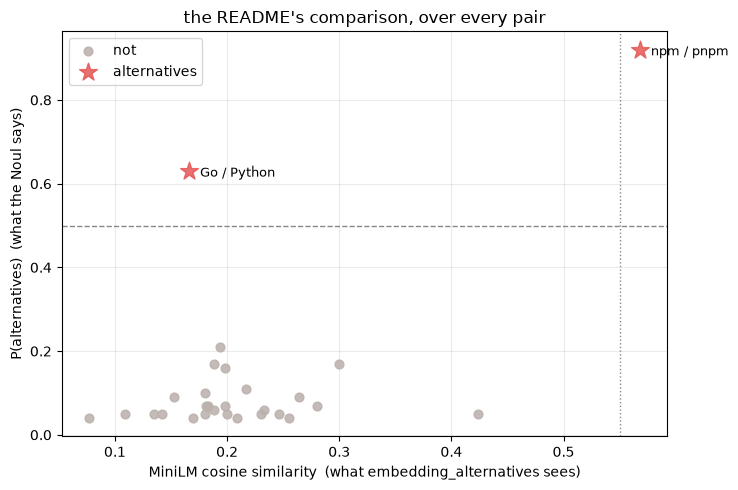

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for gold, colour, marker in [("not", "#BAB0AC", "o"), ("alternatives", "#E45756", "*")]:
    sub = PAIRS[PAIRS["gold"] == gold]
    ax.scatter(sub["cosine"], sub["p_alternatives"], c=colour, marker=marker,
               s=180 if gold == "alternatives" else 40, label=gold, alpha=0.85, zorder=3 if gold == "alternatives" else 2)
for _, r in PAIRS[PAIRS["gold"] == "alternatives"].iterrows():
    ax.annotate(f"{r.a} / {r.b}", (r.cosine, r.p_alternatives), textcoords="offset points",
                xytext=(8, -4), fontsize=9)
ax.axhline(0.5, color="#888", lw=1, ls="--"); ax.axvline(0.55, color="#888", lw=1, ls=":")
ax.set_xlabel("MiniLM cosine similarity  (what embedding_alternatives sees)")
ax.set_ylabel("P(alternatives)  (what the Noul says)")
ax.set_title("the README's comparison, over every pair")
ax.grid(alpha=0.25); ax.legend(); plt.tight_layout(); plt.show()

**A single threshold separates the two planted alternatives from all 26 other pairs for the `Noul`, and no
threshold does for cosine.** `npm` / `pnpm` comes back at 0.92 and `Python` / `Go` at 0.63; the highest of
the rest is `Go` / `Neo4j` at 0.21. MiniLM puts `npm` / `pnpm` at 0.568 — above the 0.55 cutoff by a hair —
and `Python` / `Go` at **0.166**, lower than 20 of the 26 non-alternatives. That is the README's finding
restated with numbers: the embedding is measuring string and topical similarity, and *being alternatives*
is neither. `Go` and `Python` do not look alike; they compete for the same job. The `Choice` says which
kind of pair each is, and it calls `Go` / `npm` `alternatives` at 0.17 — a wrong label at low probability,
which is what the `Noul` is for.

The 0.63 on `Python` / `Go` is worth reading honestly. It is the right side of 0.5, and it is a long way
from 0.92: two general-purpose languages are alternatives for *a* job, not for every job, and the model is
saying so. With a two-item positive class there is no distribution to fit a threshold to; 0.5 is the
uncommitted prior, and it works here. On a real corpus the level to route to review would be measured.

---

## 3. What it cost

In [14]:
stats = ts.stats()
display(pd.Series(stats).to_frame("value"))
print(f"\nGLiNER over {len(episodes)} episodes: local, no key")
print(f"pairs judged in the ingest loop: {len(jev._memo)}   directly: {len(direct._memo)}")

,value
requests_live,0.0
requests_cached,85.0
questions,170.0
questions_per_request,2.0
input_tokens_billed,0.0
output_tokens_billed,0.0
input_tokens_observed,45235.0
output_tokens_observed,6174.0
ms_spent,0.0
ms_per_request_observed,179.2



GLiNER over 25 episodes: local, no key
pairs judged in the ingest loop: 57   directly: 28


---

## 4. Findings

*Measured on this repo's corpus, not asserted. Reproducible from `output/typesafe_cache/`.*

In [15]:
print("=" * 78)
print("SUMMARY".center(78))
print("=" * 78)
print(scoreboard.to_string())
print()
print(f"direct pairs: {len(PAIRS)}   planted: {int((PAIRS['gold'] == 'alternatives').sum())}")
print(f"  System One  alternatives p in [{PAIRS[PAIRS.gold == 'alternatives'].p_alternatives.min():.2f}, "
      f"{PAIRS[PAIRS.gold == 'alternatives'].p_alternatives.max():.2f}]   "
      f"others max {PAIRS[PAIRS.gold == 'not'].p_alternatives.max():.2f}   separated: {sep_jev}")
print(f"  cosine      alternatives in [{PAIRS[PAIRS.gold == 'alternatives'].cosine.min():.2f}, "
      f"{PAIRS[PAIRS.gold == 'alternatives'].cosine.max():.2f}]   "
      f"others max {PAIRS[PAIRS.gold == 'not'].cosine.max():.2f}   separated: {sep_cos}")
print("=" * 78)

                                   SUMMARY                                    
                       supersessions via fn  true  false  missed  single-policy  review queue
alternative_fn                                                                               
none (review queue)                       0     0      0       2              2            81
embeddings @ 0.55                         1     1      0       1              2             0
`replaces` edges                          1     1      0       1              2             0
System One Noul @ 0.5                     1     1      0       1              2             0

direct pairs: 28   planted: 2
  System One  alternatives p in [0.63, 0.92]   others max 0.21   separated: True
  cosine      alternatives in [0.17, 0.57]   others max 0.42   separated: False


### The world-knowledge question has a clean answer, and it is not similarity

Over every pair of the things the gold facts name, one `Noul` — *are these alternatives?* — puts the two
planted switches at 0.92 and 0.63 and every other pair at 0.21 or below. MiniLM cosine puts `Python` / `Go`
at 0.166, below most of the non-alternatives, because it measures how alike two names are and *competing
for the same role* is not that. This is the README's claim, measured over 28 pairs rather than two, and it
is the one place in these notebooks where the judgment model is doing something no local component in the
repo can approximate.

### In the pipeline, the judge never got to show it

Ingesting the five sessions with four different `alternative_fn`s produced identical supersessions,
because extraction delivered exactly one alternatives-policy candidate that was a real switch, and even
embeddings got that one right by 0.018. `Go` was never extracted. `prefers pnpm` was extracted from the sentence in which the user turned
pnpm down. The planted `prefers` contradiction was invisible to every method for reasons
that had nothing to do with any of them. The judge is only as good as its queue — notebooks 10 and 11
found the same thing at the resolution and relation stages, and here it is again at the temporal one.

### `alternative_fn` is the right seam

`TemporalGraph(alternative_fn=JevAlternatives(ts))` is the entire integration: 57 pairs judged during
ingest, each once, each cached, each logged with its probability and its `kind`. The temporal layer's
design — decide on write, log what you could not decide — meant the judgment slotted in where the review
queue was, with no other change. A supersession the layer makes can be traced to the two names, the
probability, and the reason.

### Errors wear a disguise, again

Two of the three supersessions the layer made are `works_at Northwind Logistics → CFO` and back. No
function was consulted: `works_at` supersedes by the "single" policy, and `CFO` had been resolved as an
organisation. That is a resolution error presenting as a change of employer, and it would look like the
user changed jobs to anything reading the memory. The evidence on the fact is what makes it recognisable.